# Projekt č. 1 - Explorační analýza dat

---

# 1. Příprava dat

## Import balíčků

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import math

## Načtení dat

In [3]:
intakes = pd.read_csv('intakes.csv')
outcomes = pd.read_csv('outcomes.csv')

## Seznámení s datasety

### Dataset intakes:

**Příklad dat:**

In [4]:
intakes.sample(5)

,Animal ID,Name,DateTime,MonthYear,Found Location,Intake Type,Intake Condition,Animal Type,Sex upon Intake,Age upon Intake,Breed,Color
112366,A783722,NaN,11/05/2018 11:00:00 AM,November 2018,3108 Crownover Street in Austin (TX),Stray,Normal,Cat,Intact Female,1 month,Domestic Shorthair Mix,Calico
112328,A758777,Angel,09/21/2017 03:55:00 PM,September 2017,Austin (TX),Owner Surrender,Sick,Dog,Intact Female,3 months,Labrador Retriever Mix,Black
100359,A674288,*Rosalie,03/10/2014 06:42:00 PM,March 2014,12187 Running Bird Ln in Austin (TX),Stray,Normal,Dog,Intact Female,4 months,Catahoula Mix,Black/White
119531,A756164,Baby,09/01/2017 05:32:00 PM,September 2017,Austin (TX),Owner Surrender,Normal,Dog,Neutered Male,2 years,Akbash Mix,White
39822,A739113,Gus,11/28/2016 11:39:00 AM,November 2016,81 San Marcos St in Austin (TX),Stray,Normal,Dog,Intact Male,3 months,Anatol Shepherd,Tan/White


**Počet řádků a sloupců datasetu:**

In [5]:
intakes.shape

(138585, 12)

**Datové typy jednotlivých příznaků:**

In [6]:
intakes.dtypes

Animal ID           object
Name                object
DateTime            object
MonthYear           object
Found Location      object
Intake Type         object
Intake Condition    object
Animal Type         object
Sex upon Intake     object
Age upon Intake     object
Breed               object
Color               object
dtype: object

Všechny příznaky mají zatím datový typ 'object', musíme je tedy převést na vhodnější datové typy.

**Počet záznamů s prázdnou hodnotou v každém z příznaků (seřazené):**

In [7]:
intakes.isnull().sum().sort_values(ascending = False).head(3)

Name               41269
Sex upon Intake        1
Animal ID              0
dtype: int64

Vidíme, že hodnoty chybějí nejvíce v příznaku 'Name'. Ten pro nás naštěstí nebude důležitý. 

Ne všechny prázdné hodnoty v datasetu jsou značeny NaN, ty později za NaN nahradíme.

**Počty unikátních hodnot v každém z příznaků:**

In [8]:
intakes.nunique()

Animal ID           123890
Name                 23544
DateTime             97442
MonthYear              103
Found Location       58367
Intake Type              6
Intake Condition        15
Animal Type              5
Sex upon Intake          5
Age upon Intake         54
Breed                 2741
Color                  616
dtype: int64

Vidíme, že příznak 'Animal ID' neobsahuje pouze unikátní hodnoty. To je způsobeno tím, že některá zvířata byla do útulku přijata vícekrát a dostala pokaždé stejné ID.

Dále můžeme pozorovat, že největší počet unikátních hodnot se vyskytuje u nekategorických příznaků, což je očekávané.

### Dataset outcomes:

**Příklad dat:**

In [9]:
outcomes.sample(5)

,Animal ID,Name,DateTime,MonthYear,Date of Birth,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
75594,A713750,*Mistery,10/21/2015 01:36:00 PM,Oct 2015,10/12/2014,Transfer,Partner,Cat,Spayed Female,1 year,Domestic Medium Hair Mix,Brown Tabby/White
75048,A760886,Diamond,10/25/2017 04:39:00 PM,Oct 2017,10/25/2004,Return to Owner,NaN,Dog,Spayed Female,13 years,Cairn Terrier Mix,Tan/White
47215,A810300,NaN,12/10/2019 07:35:00 PM,Dec 2019,12/10/2017,Euthanasia,Rabies Risk,Other,Unknown,2 years,Bat,Brown
54321,A732172,Clyde,05/07/2018 06:23:00 PM,May 2018,03/04/2014,Return to Owner,NaN,Dog,Intact Male,4 years,Catahoula Mix,Brown Brindle/White
85316,A762178,NaN,11/15/2017 04:26:00 PM,Nov 2017,11/15/2016,Euthanasia,Suffering,Other,Unknown,1 year,Coyote Mix,Brown/White


**Počet řádků a sloupců datasetu:**

In [10]:
outcomes.shape

(138769, 12)

**Datové typy jednotlivých příznaků:**

In [11]:
outcomes.dtypes

Animal ID           object
Name                object
DateTime            object
MonthYear           object
Date of Birth       object
Outcome Type        object
Outcome Subtype     object
Animal Type         object
Sex upon Outcome    object
Age upon Outcome    object
Breed               object
Color               object
dtype: object

Všechny příznaky mají zatím datový typ 'object', musíme je tedy převést na vhodnější datové typy.

**Počet záznamů s prázdnou hodnotou v každém z příznaků (seřazené):**

In [12]:
outcomes.isnull().sum().sort_values(ascending=False).head(6)

Outcome Subtype     75334
Name                41255
Outcome Type           23
Age upon Outcome        5
Sex upon Outcome        1
Animal ID               0
dtype: int64

Nejvíce hodnot chybí u příznaku 'Outcome Subtype', protože častokrát 'Outcome Type' hovoří za sebe. 

Ne všechny prázdné hodnoty v datasetu jsou značeny NaN, ty později za NaN nahradíme.

**Počty unikátních hodnot v každém z příznaků:**

In [13]:
outcomes.nunique()

Animal ID           124068
Name                 23425
DateTime            115364
MonthYear              103
Date of Birth         7576
Outcome Type             9
Outcome Subtype         26
Animal Type              5
Sex upon Outcome         5
Age upon Outcome        54
Breed                 2749
Color                  619
dtype: int64

Opět vidíme, že příznak 'Animal ID' neobsahuje pouze unikátní hodnoty.

## Čištění a konverze dat

### Přepis chybějících hodnot na NaN
Jediný příznak, který nemá chybějící hodnoty označené NaN, je 'Sex upon Intake' / 'Sex upon Outcome', kde je chybějící hodnota značená hodnotou 'Unknown'. Dále by se za chybějící hodnotu dala považovat hodnota 'Other' u příznkau 'Animal Type', já ji však za chybějící nepovažuji. 

In [14]:
intakes['Sex upon Intake'] = intakes['Sex upon Intake'].replace('Unknown', np.nan)
outcomes['Sex upon Outcome'] = outcomes['Sex upon Outcome'].replace('Unknown', np.nan)

print('Sex upon Intake NaNs: ', intakes['Sex upon Intake'].isnull().sum())
print('Sex upon Outcome NaNs: ', outcomes['Sex upon Outcome'].isnull().sum())

Sex upon Intake NaNs:  11070
Sex upon Outcome NaNs:  11053


### Převod kategorických příznaků na typ category

In [15]:
catFeatures = {
    'intakes': ['Animal Type', 'Breed', 'Color', 'Intake Type',
                'Intake Condition', 'Sex upon Intake', 'Animal ID',
                'Name', 'MonthYear', 'Found Location', 'Age upon Intake'], 
    'outcomes': ['Animal Type', 'Breed', 'Color', 'Outcome Type', 
                'Outcome Subtype', 'Sex upon Outcome', 'Animal ID',
                'Name', 'Age upon Outcome', 'MonthYear']
}

outcomes[catFeatures['outcomes']
         ] = outcomes[catFeatures['outcomes']].astype('category')

intakes[catFeatures['intakes']
         ] = intakes[catFeatures['intakes']].astype('category')

### Převod 'Age upon Intake' / 'Age upon Outcome' na numerický příznak

Vytvořím si funkci, která převede řetězec s týdny / měsíci / roky na číslo udávající stáří v letech.

In [16]:
def ageToYears(age):
    if type(age) != str or len(age) == 0:
        return np.nan

    age = age.split()
    age[0] = int(age[0])

    if age[1] in ['week', 'weeks']:
        return age[0] / (365 / 7)

    elif age[1] in ['month', 'months']:
        return age[0] / 12

    else:
        return age[0]

Nyní funkci aplikuji na příslušné příznaky. Původní příznak ponechám a převod realizuji do nového sloupce.

In [17]:
intakes['Age upon Intake Years'] = intakes['Age upon Intake'].apply(ageToYears)
outcomes['Age upon Outcome Years'] = outcomes['Age upon Outcome'].apply(ageToYears)

Podívám se na vzorek dat a zkontroluji, jestli výstup sedí.

In [18]:
intakes[['Age upon Intake', 'Age upon Intake Years']].sample(15)

,Age upon Intake,Age upon Intake Years
124719,2 years,2.000000
113038,5 months,0.416667
106744,4 years,4.000000
86707,5 months,0.416667
25015,5 years,5.000000
113947,13 years,13.000000
70978,2 weeks,0.038356
117285,7 months,0.583333
51979,2 years,2.000000
66161,4 years,4.000000


Na tomto vzorku dat je výstup správný. Budu předpokládat, že je výstup správný u všech záznamů.

### Převod 'DateTime' na datetime64

In [19]:
intakes['DateTime'] = intakes['DateTime'].astype('datetime64')
outcomes['DateTime'] = outcomes['DateTime'].astype('datetime64')


### Převod 'Date of Birth' na datetime64

In [20]:
outcomes['Date of Birth'] = outcomes['Date of Birth'].astype('datetime64')

Převedl jsem všechny potřebné příznaky na vhodnější datové typy.

Nyní se můžeme podívat na výsledné datové typy jednotlivých příznaků:

In [21]:
display(intakes.dtypes)
display(outcomes.dtypes)

Animal ID                      category
Name                           category
DateTime                 datetime64[ns]
MonthYear                      category
Found Location                 category
Intake Type                    category
Intake Condition               category
Animal Type                    category
Sex upon Intake                category
Age upon Intake                category
Breed                          category
Color                          category
Age upon Intake Years           float64
dtype: object

Animal ID                       category
Name                            category
DateTime                  datetime64[ns]
MonthYear                       category
Date of Birth             datetime64[ns]
Outcome Type                    category
Outcome Subtype                 category
Animal Type                     category
Sex upon Outcome                category
Age upon Outcome                category
Breed                           category
Color                           category
Age upon Outcome Years           float64
dtype: object

In [22]:
intakes.nunique()

Animal ID                123890
Name                      23544
DateTime                  97442
MonthYear                   103
Found Location            58367
Intake Type                   6
Intake Condition             15
Animal Type                   5
Sex upon Intake               4
Age upon Intake              54
Breed                      2741
Color                       616
Age upon Intake Years        47
dtype: int64

### Odstranění duplicitních záznamů

In [23]:
intakes = intakes.drop_duplicates()
outcomes = outcomes.drop_duplicates()

Podíváme se na nynější počty záznamů:

In [24]:
print('Intakes:',intakes.shape[0])
print('Outcomes:',outcomes.shape[0])

Intakes: 138565
Outcomes: 138752


V každém datasetu se vyskytovalo pouze pár desítek duplicitních záznamů.

In [25]:
intakes.sample(10)

,Animal ID,Name,DateTime,MonthYear,Found Location,Intake Type,Intake Condition,Animal Type,Sex upon Intake,Age upon Intake,Breed,Color,Age upon Intake Years
30418,A738394,NaN,2016-11-14 13:06:00,November 2016,11901 N Mopac Expy in Austin (TX),Stray,Normal,Cat,Intact Female,2 years,Domestic Shorthair Mix,Calico,2.000000
12283,A664960,G.O.D.,2013-10-11 15:56:00,October 2013,7014 Ellroy Rd in Travis (TX),Stray,Normal,Dog,Intact Female,9 months,Pit Bull Mix,Black/White,0.750000
119608,A772248,NaN,2018-05-16 15:20:00,May 2018,7801 N Lamar Blvd in Austin (TX),Wildlife,Normal,Other,NaN,2 years,Bat Mix,Brown,2.000000
37437,A802914,Nomad,2019-08-24 14:58:00,August 2019,912 East William Cannon Drive in Austin (TX),Stray,Normal,Cat,Intact Female,1 month,Siamese Mix,Lynx Point,0.083333
81593,A669270,Zorro,2014-07-10 11:44:00,July 2014,William Cannon/ Sneed in Austin (TX),Stray,Normal,Dog,Neutered Male,8 months,English Foxhound Mix,White/Brown,0.666667
83932,A743336,NaN,2017-02-08 16:06:00,February 2017,302 E Powell #B in Austin (TX),Wildlife,Sick,Other,NaN,2 years,Raccoon Mix,Black/White,2.000000
66791,A796499,Palta,2019-06-02 13:09:00,June 2019,Austin (TX),Stray,Normal,Cat,Intact Female,1 month,Domestic Shorthair Mix,Black,0.083333
48105,A680950,NaN,2014-06-10 12:11:00,June 2014,7905 San Felipe Blvd in Austin (TX),Stray,Normal,Cat,Intact Female,2 years,Domestic Shorthair Mix,Black,2.000000
85615,A703418,Pablo,2015-05-24 14:15:00,May 2015,1941 Webberville Rd in Austin (TX),Stray,Normal,Dog,Intact Male,1 year,Chihuahua Shorthair Mix,Brown,1.000000
132914,A846110,A846110,2021-11-10 07:59:00,November 2021,Wells Branch Parkway And Alex Avenue in Travis...,Stray,Injured,Cat,Intact Male,6 months,Domestic Medium Hair,Brown Tabby/White,0.500000


# 2. Deskriptivní statistiky

## Popis příznaku 'Age upon Intake'

Nejprve vypíšu některé popisné statistiky.

In [26]:
intakeAgeFiltered = intakes['Age upon Intake Years'][intakes['Age upon Intake Years'] >= 0].dropna()
stats = {
    'count' :intakeAgeFiltered.shape[0],
    'min' : intakeAgeFiltered.min(),
    'max' : intakeAgeFiltered.max(),
    'mean' : intakeAgeFiltered.mean(),
    'median' : intakeAgeFiltered.median(),
    'mode' : intakeAgeFiltered.mode()[0],
    'standard deviation' : intakeAgeFiltered.std(),
    'variance' : intakeAgeFiltered.var()
}

for stat in stats:
    print(f'{stat}: {stats[stat]:g}')

count: 138557
min: 0
max: 30
mean: 2.09103
median: 1
mode: 1
standard deviation: 2.85555
variance: 8.15417


Vidíme, že jsou hodnoty koncentrované okolo 1 roku věku.

Nyní vykreslím graf, který zobrazuje počet přijatých zvířat podle jejich věku.

Věk zobrazuji jako stáří v celých letech, tedy pokud má zvíře například 6 měsíců, jeho věk je 0. 

Text(0.5, 1.0, 'Number of intaken animals based on their age (log scale)')

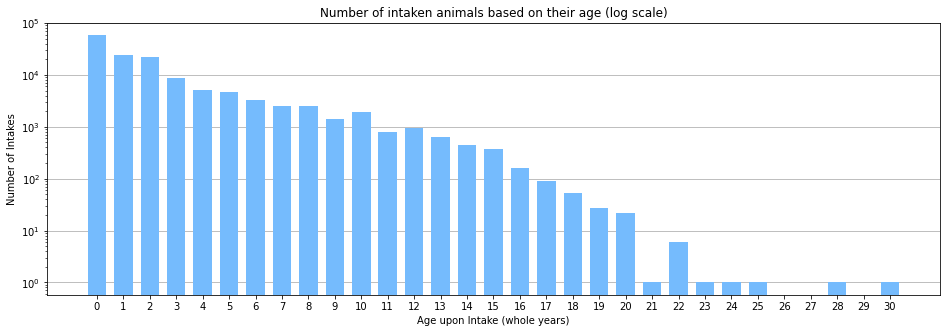

In [27]:
intakeAgeCount = intakeAgeFiltered.apply(math.floor).value_counts()

fig, ax = plt.subplots(figsize=(16,5))

ax.grid(axis='y', color='black', alpha=.5, linewidth=.5)
ax.set_axisbelow(True)

ax.bar(intakeAgeCount.keys(), intakeAgeCount.values, width=0.7, align='center',
       bottom=0, color='xkcd:sky blue')

fmt = ticker.FixedLocator(range(0, max(intakeAgeCount.keys()) + 1))
ax.xaxis.set_major_locator(fmt)

ax.set_yscale('log')

ax.set_xlabel('Age upon Intake (whole years)')
ax.set_ylabel('Number of Intakes')

ax.set_title('Number of intaken animals based on their age (log scale)')

Z grafu je zřejmé, že počet přijatých zvířat klesá exponenciálně s jejich věkem. Proto jsem použil logaritmické měřítko.

Dále vykreslím krabicový graf, ze kterého bude zřejmá koncentrovanost okolo 1 roku věku.

Text(0.5, 1.0, 'Age upon intake distribution')

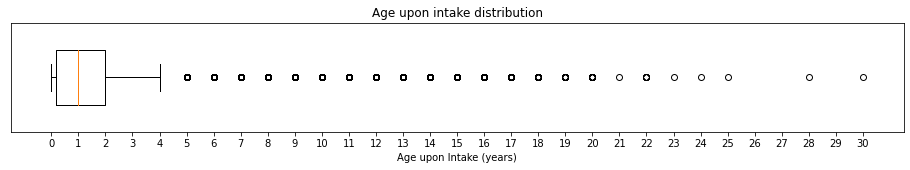

In [28]:
fig, ax = plt.subplots(figsize=(16,2))

ax.boxplot(intakeAgeFiltered, vert=False, widths=[0.5])

ax.set_yticks([])
fmt = ticker.FixedLocator(range(0, max(intakeAgeCount.keys()) + 1))
ax.xaxis.set_major_locator(fmt)
ax.set_xlabel('Age upon Intake (years)')

ax.set_title('Age upon intake distribution')

Vidíme, že příznak Age upon Intake obsahuje hodně odlehlých hodnot.

Podíváme se ještě na četnosti stáří bez logaritmického měřítka.

Text(0.5, 1.0, 'Age upon Intake frequency')

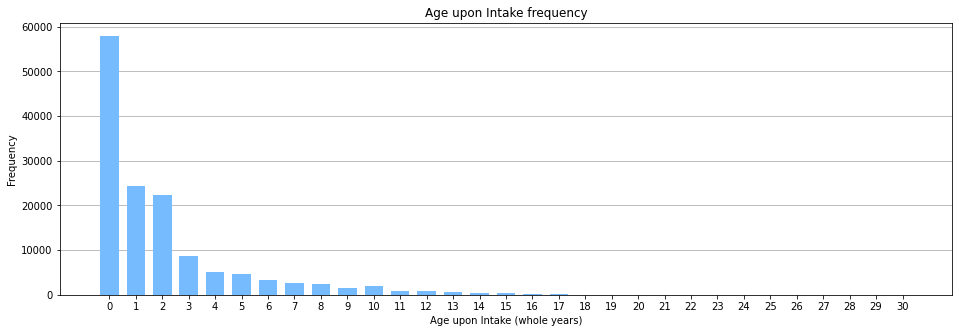

In [29]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.grid(axis='y', color='black', alpha=.5, linewidth=.5)
ax.set_axisbelow(True)

ax.bar(intakeAgeCount.keys(), intakeAgeCount.values, width=0.7, align='center',
       bottom=0, color='xkcd:sky blue')

fmt = ticker.FixedLocator(range(0, max(intakeAgeCount.keys()) + 1))
ax.xaxis.set_major_locator(fmt)
ax.set_xlabel('Age upon Intake (whole years)')
ax.set_ylabel('Frequency')

ax.set_title('Age upon Intake frequency')

## Popis příznaku 'DateTime' (intakes)

Nejprve vypíšu některé popisné statistiky. Protože se jedná o datum, použiju vhodnější označení statistik.

In [30]:
dateTimeFiltered = intakes['DateTime'].dropna()
stats = {
    'count': dateTimeFiltered.shape[0],
    'first record': dateTimeFiltered.min().strftime('%Y-%m-%d'),
    'last record': dateTimeFiltered.max().strftime('%Y-%m-%d'),
    'days total': (dateTimeFiltered.max() - dateTimeFiltered.min()).days,
    'years total': round((dateTimeFiltered.max() - dateTimeFiltered.min()).days / 365.25, 2),
    'mean': dateTimeFiltered.mean().strftime('%Y-%m-%d'),
    'median': dateTimeFiltered.median().strftime('%Y-%m-%d'),
    'standard deviation (days)': dateTimeFiltered.std().days
}

for stat in stats:
    print(f'{stat}: {stats[stat]}')

count: 138565
first record: 2013-10-01
last record: 2022-04-27
days total: 3130
years total: 8.57
mean: 2017-09-03
median: 2017-07-20
standard deviation (days): 863


Z těchto statistik se zatím zdá činnost instituce v průběhu času poměrně konzistentní.

Vytvořím vizualizaci zobrazující počet přijatých zvířat v každém roce.

Záměrně odstraním rok 2022, protože ještě není kompletní a graf by byl zavádějící (zejména bez uvedení měsíce vytvoření). Rok 2013 naopak ponechám, protože jeho data se již nebudou měnit.

Text(0.5, 1.0, 'Number of intakes each year')

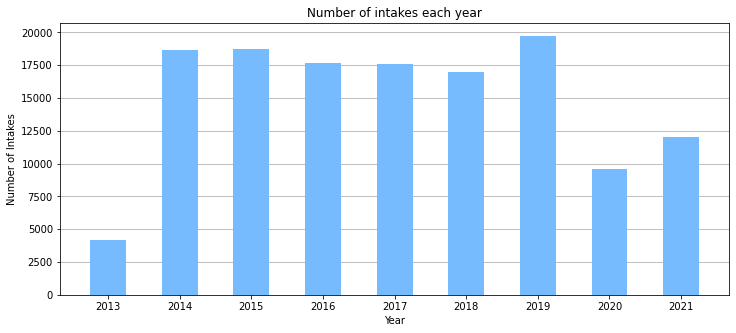

In [31]:
fig, ax = plt.subplots(figsize=(12,5))

yearCount = pd.DatetimeIndex(
    intakes['DateTime'].dropna()).year.value_counts().sort_index()
del yearCount[2022]
ax.bar(yearCount.keys(), yearCount.values, width=0.5, align='center',
       bottom=0, color='xkcd:sky blue')


ax.grid(axis='y', color='black', alpha=.5, linewidth=.5)
ax.set_axisbelow(True)

ax.set_xticks(yearCount.keys())
ax.set_xticklabels(yearCount.keys())

ax.set_xlabel('Year')
ax.set_ylabel('Number of Intakes')

ax.set_title('Number of intakes each year')


Z vizualizace je zřejmé, že počet přijatých zvířat od roku 2020 klesl. Dá se předpokládat, že tento pokles byl způsoben pandemií.

In [32]:
min(intakes['DateTime'])

Timestamp('2013-10-01 07:51:00')

Vidíme, že první záznam je z října 2013, což vysvětluje menší počet přijatých zvířat v roce 2013.

## Popis příznaku 'Intake Type'

Jedná se o kategorický příznak. Zobrazím tedy četnost jednotlivých hodnot.

In [33]:
def freqTable(feature):
    counts = feature.value_counts()
    freq = pd.DataFrame()
    freq[feature.name] = counts.keys()
    freq['Frequency'] = counts.values
    freq['Relative Frequency'] = counts.values / counts.values.sum()
    freq.set_index(feature.name, inplace=True)
    return freq

In [34]:
freq = freqTable(intakes['Intake Type'])

display(freq)

,Frequency,Relative Frequency
Intake Type,,
Stray,95275,0.687583
Owner Surrender,28575,0.206221
Public Assist,8344,0.060217
Wildlife,5372,0.038769
Abandoned,740,0.005340
Euthanasia Request,259,0.001869


Vykreslím graf zobrazující absolutní četnost jednotlivých hodnot.

In [35]:
def plotFreq(freq, log = False, colors = None):
    fig, ax = plt.subplots(figsize=(12, 5))
    
    if colors is None:
        colors = ['xkcd:sky blue', 'xkcd:salmon', 'xkcd:sage',
                  'xkcd:light orange', 'xkcd:dark lavender', 'xkcd:dirt']


    ax.bar(freq.index, freq['Frequency'], width=0.5, color=colors)


    ax.grid(axis='y', color='black', alpha=.5, linewidth=.5)
    ax.set_axisbelow(True)


    ax.set_xlabel(freq.index.name)
    ax.set_ylabel('Count')

    ax.set_title(f'{freq.index.name} frequencies')
    
    if log:
        ax.set_yscale('log')
        ax.set_title(f'{freq.index.name} frequencies (log scale)')


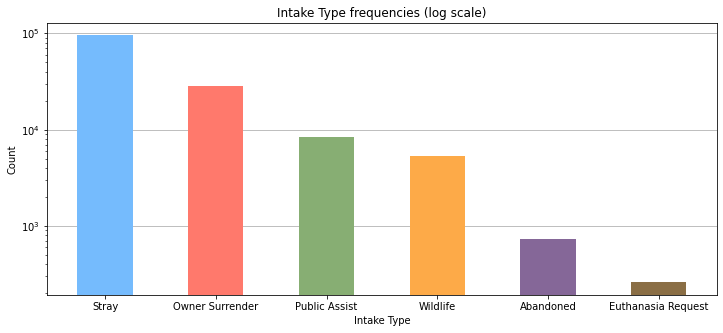

In [36]:
plotFreq(freq, log=True)


Četnosti jednotlivých hodnot jsou značně nevyrovnané, proto jsem použil logarimické měřítko. Vidíme, že zdaleka nejvíce přijatých zvířat bylo toulavých.

Koláčový graf relativní četnosti vykreslovat nebudu, protože přibližně 90 % grafu by zabíraly pouze 2 hodnoty.

## Popis příznaku 'Sex upon Intake'

Jedná se o kategorický příznak. Zobrazím tedy četnost jednotlivých hodnot.

In [37]:
freq = freqTable(intakes['Sex upon Intake'])
display(freq)

,Frequency,Relative Frequency
Sex upon Intake,,
Intact Male,45629,0.357880
Intact Female,43303,0.339637
Neutered Male,20835,0.163414
Spayed Female,17731,0.139069


Absolutní četnost vyreslím na následujícím grafu.

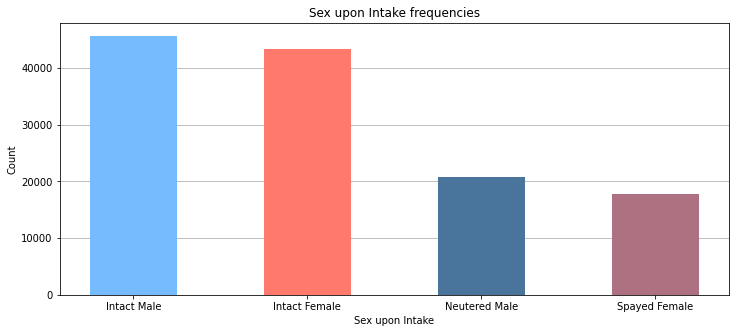

In [38]:
colors = ['xkcd:sky blue', 'xkcd:salmon', 'xkcd:dull blue', 'xkcd:mauve']
plotFreq(freqTable(intakes['Sex upon Intake']), colors=colors)

Vidíme, že nedotčených zvířat obou pohlaví bylo přijato více než 2x více.

Dále ještě vykreslím koblihový graf zobrazující relativní četnost hodnot.

Text(0.5, 1.0, 'Sex upon Intake relative frequency')

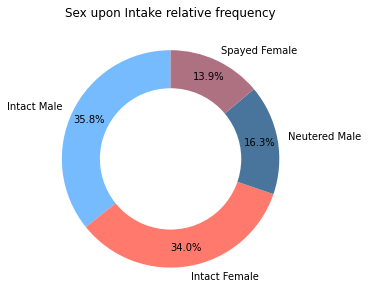

In [39]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.pie(freq['Relative Frequency'], colors=colors, autopct='%1.1f%%', pctdistance=0.83, startangle=90, labels=freq.index)

circle = plt.Circle((0, 0), 0.65, fc='white')
ax.add_artist(circle)

fig.patch.set_facecolor('white')

ax.set_title('Sex upon Intake relative frequency')

Zde vidíme, jakou část přijatých zvířat zabírají jednotlivé hodnoty pohlaví.

## Popis příznaku 'Animal Type' (intakes)

Jedná se opět o příznak kategorický. Vypíšu tedy četnosti jednotlivých hodnot.

In [40]:
freq = freqTable(intakes['Animal Type'])
display(freq)

,Frequency,Relative Frequency
Animal Type,,
Dog,78135,0.563887
Cat,52373,0.377967
Other,7372,0.053202
Bird,661,0.004770
Livestock,24,0.000173


Vidíme převahu psů a koček. Dobytek se v útulku vyskytoval vzácně.

Vykreslím graf absolutní četnosti.

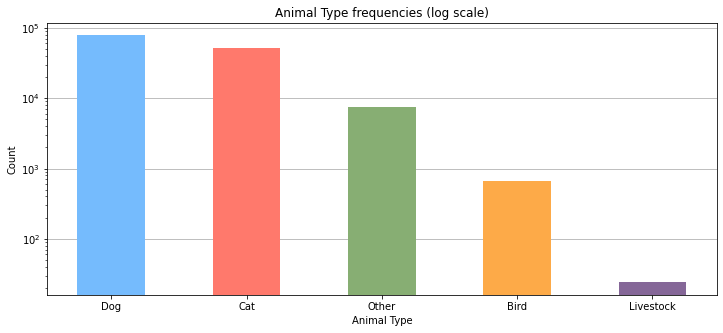

In [41]:
plotFreq(freq, log=True)

Byl jsem nucen použít logaritmické měřítko kvůli převaze psů a koček.

## Popis vztahu příznaků 'Outcome Type' a 'Sex upon Outcome'

Příznaky typ vydání zvířete a pohlaví při vydání by mohly korelovat. Podíváme se tedy na teplotní mapu zobrazující vztah mezi těmito dvěma příznaky.

Text(0.5, 1.0, 'Relationship between outcome type and sex upon outcome')

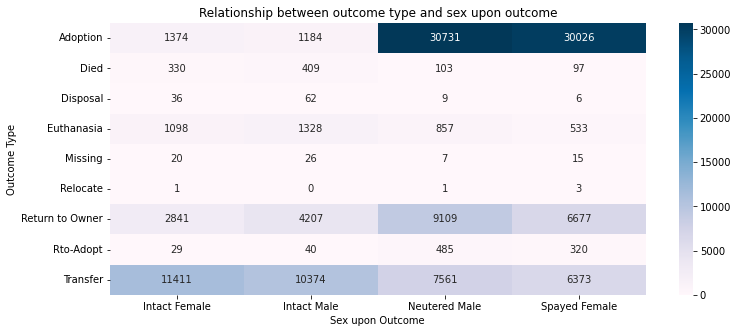

In [42]:
cross = pd.crosstab(outcomes['Outcome Type'], outcomes['Sex upon Outcome'])

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(cross, annot=True, fmt='d', cmap='PuBu', ax=ax)

ax.set_title('Relationship between outcome type and sex upon outcome')

Korelace se potvrdila. Z mapy je zřejmé, že zvířata vydaná k adopci byla z velké části vykastrovaná. Naopak u zvířat, která byla přesunuta do jiného útulku, kastrace tolik podstatná nebyla (jak jsme se dozvěděli z příznaku 'Sex upon Intake', útulek přijímal většinou nedotčená zvířata), dokonce byla zvířata spíše nedotčená.

# Zadané otázky

## Závisí typ odchodu zvířete z útulku na typu příchodu?

Nejprve vyfiltruji z datasetů zvířata s mnohonásobným výskytem.

In [43]:
intakesIdCount = intakes['Animal ID'].value_counts()
intakesSingleIDs = intakesIdCount[intakesIdCount == 1].keys()

outcomesIdCount = outcomes['Animal ID'].value_counts()
outcomesSingleIDs = outcomesIdCount[outcomesIdCount == 1].keys()

singleIDs = [ID for ID in intakesSingleIDs if ID in outcomesSingleIDs]

intakesFiltered = intakes[intakes['Animal ID'].isin(singleIDs)]
outcomesFiltered = outcomes[outcomes['Animal ID'].isin(singleIDs)]

Nyní spojím datasety podle ID.

In [44]:
intakesOutcomes = pd.merge(intakesFiltered, outcomesFiltered, on='Animal ID', how='inner')

Vykreslím teplotní mapu, která zobrazí vztah mezi příznaky 'Intake Type' a 'Outcome Type'.

Text(0.5, 1.0, 'Relationship between intake type and outcome type')

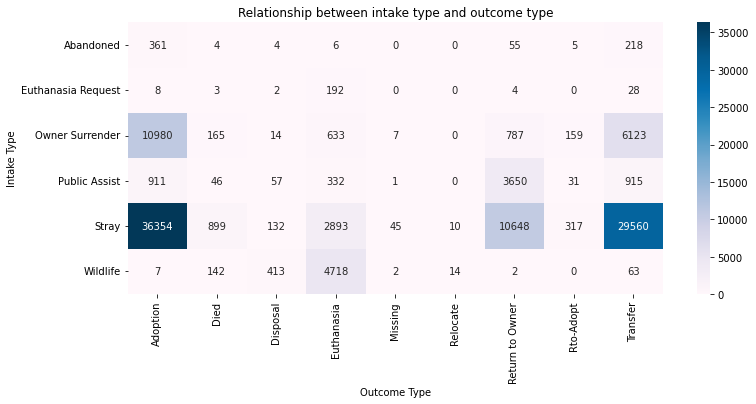

In [45]:
cross = pd.crosstab(intakesOutcomes['Intake Type'], intakesOutcomes['Outcome Type'])

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(cross, annot=True, fmt='d', cmap='PuBu', ax=ax)

ax.set_title('Relationship between intake type and outcome type')

Typ odchodu na typu příchodu závisí.

Vidíme, že nejvýraznější buňka je v průniku toulavých zvířat a adopce, avšak tato četnost je způsobena tím, že útulek přijímal nejvíce zvířat toulavých a nejvíce zvířat odevzdával k adopci. 

Zajímavější závislostí je průnik divokých zvířat a eutanázie. Vidíme, že k eutanázii jsou nejčastěji dána divoká zvířata a zároveň divoká zvířata nejčastěji končí eutanazií.

## Hraje věk zvířete roli při adopci?

Vykreslím graf, který zobrazí relativní četnost adopce pro každý věk opuštění útulku.

Opět uvažuji věk v celých letech.

Text(0.5, 1.0, 'Relative adoption frequency for each age upon outcome')

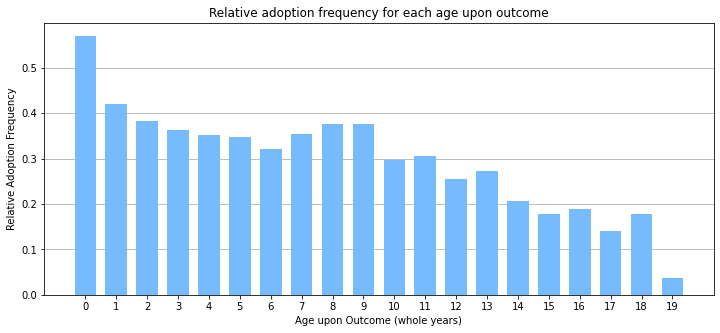

In [46]:
fig, ax = plt.subplots(figsize=(12, 5))

outcomeAgeFiltered = outcomes['Age upon Outcome Years'][outcomes['Age upon Outcome Years'] >= 0].dropna()
ageCount = outcomeAgeFiltered.apply(math.floor).value_counts()

outcomeAgeAdoption = outcomeAgeFiltered[outcomes['Outcome Type'] == 'Adoption']
adoptionAgeCount = outcomeAgeAdoption.apply(math.floor).value_counts()

perc = {}
for age in adoptionAgeCount.keys():
    perc[age] = adoptionAgeCount[age] / ageCount[age]

ax.grid(axis='y', color='black', alpha=.5, linewidth=.5)
ax.set_axisbelow(True)

ax.bar(perc.keys(), perc.values(), width=0.7,color='xkcd:sky blue')

fmt = ticker.FixedLocator(range(0, max(perc.keys()) + 1))
ax.xaxis.set_major_locator(fmt)

ax.set_xlabel('Age upon Outcome (whole years)')
ax.set_ylabel('Relative Adoption Frequency')

ax.set_title('Relative adoption frequency for each age upon outcome')


Věk zvířete roli při adopci hraje.

Vidíme, že čím je zvíře mladší, tím má větší šanci na adopci.

Dokonce více než polovina zvířat, která opustila útulek v prvním roce života, byla adptována.

## Je příjem zvířat v rámci roku konstantní nebo existují období s větší/nižší zátěží?

Vykreslím graf, který zobrazí průměrný počet přijatých zvířat každý měsíc.

Text(0.5, 1.0, 'Mean number of intakes each month')

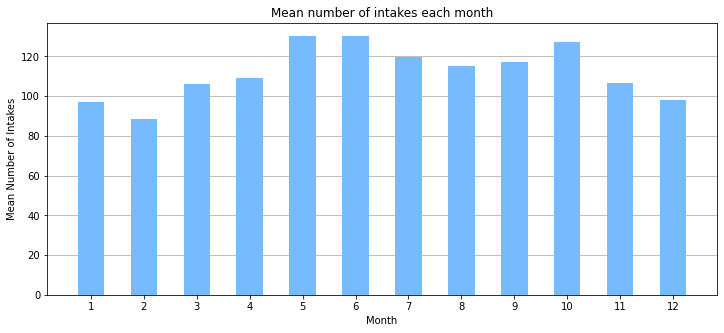

In [47]:
intakesMonth = pd.DataFrame()

intakesMonth['MonthYear'] = intakes['MonthYear']
intakesMonth['Month'] = intakes['DateTime'].apply(lambda x: x.month)
intakesMonth['Number of Intakes'] = 1

# count number of intakes each month and year
intakesMonth = intakesMonth.groupby(['MonthYear', 'Month']).sum()

# get the mean number of intakes each month
intakesMonth = intakesMonth.groupby('Month').mean()['Number of Intakes']

fig, ax = plt.subplots(figsize=(12, 5))

ax.grid(axis='y', color='black', alpha=.5, linewidth=.5)
ax.set_axisbelow(True)

ax.bar(intakesMonth.keys(), intakesMonth.values, width=0.5, color='xkcd:sky blue')

ax.set_xticks(range(1, 13))

ax.set_xlabel('Month')
ax.set_ylabel('Mean Number of Intakes')

ax.set_title('Mean number of intakes each month')


Příjem zvířat v průběhu roku není konstantní.

Vidíme, že průměrný počet přijatých zvířat je větší v teplejších měsících.

Největší zátěž bývá v květnu a červenci, naopak nejmenší zátěž bývá v únoru.

# Vlastní otázky

## Jaké jsou nejčastější příčiny eutanazie?

Vykreslím graf četností jednotlivých příčin eutanazie.

Text(0.5, 1.0, 'Frequency of causes of euthanasia')

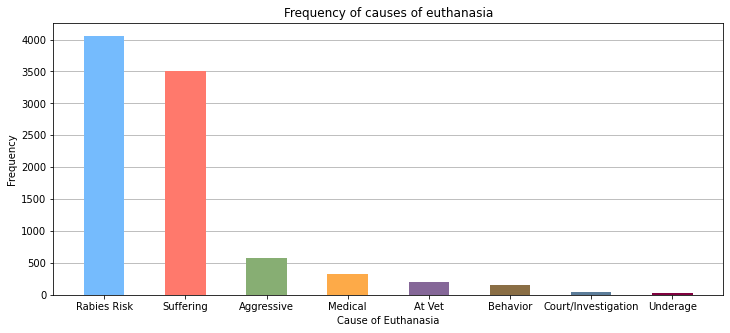

In [48]:
causes = outcomes[outcomes['Outcome Type'] == 'Euthanasia']['Outcome Subtype'].value_counts()
causes = causes[causes > 0]

fig, ax = plt.subplots(figsize=(12, 5))

ax.grid(axis='y', color='black', alpha=.5, linewidth=.5)
ax.set_axisbelow(True)

colors = ['xkcd:sky blue', 'xkcd:salmon', 'xkcd:sage',
        'xkcd:light orange', 'xkcd:dark lavender', 'xkcd:dirt',
        'xkcd:slate blue', 'xkcd:wine']

ax.bar(causes.keys(), causes.values, width=0.5, color=colors)

ax.set_xlabel('Cause of Euthanasia')
ax.set_ylabel('Frequency')

ax.set_title('Frequency of causes of euthanasia')


Vidíme, že nejčastěji byla přiváděna k eutanazii zvířata s rizikem vztekliny. Dále byla často přiváděna zvířata k eutanazii, protože trpěla.

## Jsou starší zvířata častěji nemocná při přijetí? 

Odpověď zobrazím na grafu relativní četnosti nemocných zvířat pro každý věk (v celých letech) přijatých zvířat.

Text(0.5, 1.0, 'Relative frequency of sick condition for each age upon intake')

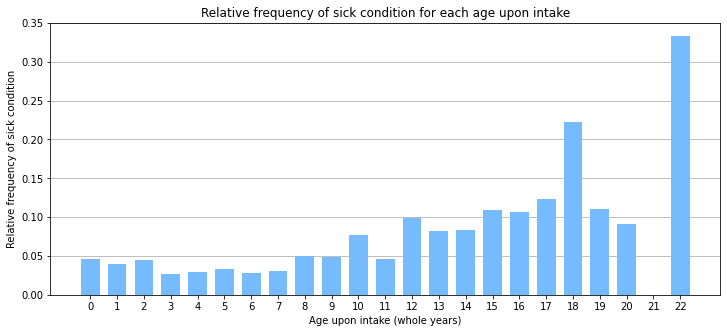

In [49]:
sick = intakes[intakes['Intake Condition'] == 'Sick']
sickAge = sick['Age upon Intake Years'][sick['Age upon Intake Years'] >= 0].dropna()
sickAge = sickAge.apply(math.floor).value_counts()
sickAgeRelative = sickAge / intakeAgeCount

fig, ax = plt.subplots(figsize=(12, 5))

ax.grid(axis='y', color='black', alpha=.5, linewidth=.5)
ax.set_axisbelow(True)

ax.bar(sickAgeRelative.keys(), sickAgeRelative.values,
       width=0.7, color='xkcd:sky blue')

fmt = ticker.FixedLocator(range(0, max(sickAge.keys()) + 1))
ax.xaxis.set_major_locator(fmt)

ax.set_xlabel('Age upon intake (whole years)')
ax.set_ylabel('Relative frequency of sick condition')

ax.set_title('Relative frequency of sick condition for each age upon intake')


Ano, starší zvířata jsou častěji nemocná při přijetí.

Vidíme, že relativní četnost nemocnosti zvířat roste s jejich věkem. Růst začíná od osmi let věku. U zvířat mladších osmi let je nemocnost zhruba konstantní.

## Liší se věk při přijetí u jednotlivých zvířat?

Zobrazím distribuci věku každého z typů zvířat na krabicovém grafu.

Text(0.5, 1.0, 'Age upon intake distribution of different animal types')

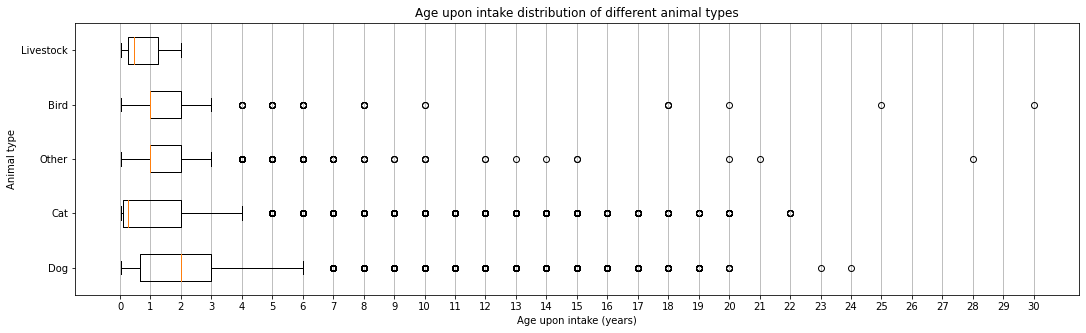

In [50]:
animalTypes = intakes['Animal Type'].unique()

animalAges = []
for animalType in animalTypes:
    animalAge = intakes[intakes['Animal Type'] == animalType]['Age upon Intake Years']
    animalAge = animalAge[animalAge > 0].dropna()
    animalAges.append(animalAge)
    
fig, ax = plt.subplots(figsize=(18, 5))

ax.grid(axis='x', color='black', alpha=.5, linewidth=.5)
ax.set_axisbelow(True)

ax.boxplot(animalAges, vert=False)

ax.set_yticklabels(animalTypes)
ax.set_xticks(range(0, int(max(intakes['Age upon Intake Years'])) + 1))

ax.set_xlabel('Age upon intake (years)')
ax.set_ylabel('Animal type')

ax.set_title('Age upon intake distribution of different animal types')

Věk při přijetí jednotlivých zvířat se do určité míry liší.

Rozdíly mezi zvířaty jsou patrné, avšak většina hodnot u všech druhů se nachází v prvních 3 letech.

Nejmladší při přijetí bývají kočky, u kterých je dokonce median blízko 0. Naopak nejstarší bývají psi s medianem ve 2 letech a 3. kvartilem ve 3 letech.